<a href="https://colab.research.google.com/github/Dharsh0109/AvianShield/blob/main/DS_Day01_51_Construction_Delays.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS_Day01_51 — Why are construction projects getting delayed?

**Synthetic-data demonstration.** This notebook creates 400 simulated projects, examines progress at five milestones, makes four charts, trains a Random Forest using foundation-stage data, evaluates it on unseen projects, and proposes an operational action plan. The generated patterns are assumptions of the simulation, not findings from real sites.


## 1. Setup and column definitions
Run cells from top to bottom in Google Colab. Colab includes common data science packages; the next cell installs compatible versions if needed.

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib joblib

In [2]:
"""Reproducible synthetic construction portfolio and delay-risk analysis."""
from pathlib import Path
import json

import joblib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

ROOT = Path.cwd()
DATA = ROOT / "data" / "synthetic_projects.csv"
OUT = ROOT / "outputs"
CHARTS = OUT / "charts"
MILESTONES = ["Planning", "Foundation", "Structure", "Services", "Finishing"]
CATEGORIES = ["Road", "Bridge", "Residential", "Commercial"]
FEATURES = ["Project_Category", "Project_Size", "Budget", "Workforce", "Material_Delivery", "Weather", "Contractor", "Planned_Progress", "Actual_Progress", "Progress_Gap"]




## 2. Generate and inspect synthetic data
Each project has five milestone records. The fixed random seed makes this dataset reproducible. Material, weather, workforce, and project difficulty are built into the simulation.

In [3]:
def generate():
    rng = np.random.default_rng(51)
    rows = []
    for i in range(1, 401):
        category = rng.choice(CATEGORIES)
        size = int(rng.integers(15, 121))  # standardized complexity score
        budget = round(size * rng.uniform(7, 13), 1)  # illustrative ₹ lakh
        workforce = int(max(8, size * rng.uniform(.55, 1.35)))
        contractor = rng.choice(["A", "B", "C", "D"])
        weather = rng.choice(["Clear", "Rain", "Severe"], p=[.62, .29, .09])
        material = rng.choice(["On time", "Minor delay", "Major delay"], p=[.58, .29, .13])
        # Latent project difficulty creates consistent correlations across milestones.
        difficulty = (size - 65) / 65 + (contractor == "D") * .35 + rng.normal(0, .5)
        material_effect = {"On time": 0, "Minor delay": 1.5, "Major delay": 4.5}[material]
        weather_effect = {"Clear": 0, "Rain": 1.2, "Severe": 3.2}[weather]
        crew_effect = max(0, size * .8 - workforce) * .055
        previous = 0.
        for stage, planned in zip(MILESTONES, [10, 30, 55, 80, 100]):
            stage_factor = {"Planning": .35, "Foundation": 1.0, "Structure": 1.5, "Services": 1.15, "Finishing": .8}[stage]
            drift = max(0, (1.4 + material_effect + weather_effect + crew_effect + difficulty) * stage_factor + rng.normal(0, 1.8))
            previous += drift
            actual = round(max(0, min(100, planned - previous)), 1)
            rows.append({"Project_ID": f"P{i:04d}", "Project_Category": category,
                         "Project_Size": size, "Budget": budget, "Workforce": workforce,
                         "Material_Delivery": material, "Weather": weather, "Contractor": contractor,
                         "Milestone": stage, "Planned_Progress": planned, "Actual_Progress": actual})
    DATA.parent.mkdir(exist_ok=True)
    pd.DataFrame(rows).to_csv(DATA, index=False)




In [4]:
generate()
df_preview = pd.read_csv(DATA)
print("Shape:", df_preview.shape)
print("Unique projects:", df_preview.Project_ID.nunique())
print("Missing values:", int(df_preview.isna().sum().sum()))
display(df_preview.head())

Shape: (2000, 11)
Unique projects: 400
Missing values: 0


,Project_ID,Project_Category,Project_Size,Budget,Workforce,Material_Delivery,Weather,Contractor,Milestone,Planned_Progress,Actual_Progress
0,P0001,Bridge,114,1008.1,85,On time,Rain,B,Planning,10,5.6
1,P0001,Bridge,114,1008.1,85,On time,Rain,B,Foundation,30,23.0
2,P0001,Bridge,114,1008.1,85,On time,Rain,B,Structure,55,45.2
3,P0001,Bridge,114,1008.1,85,On time,Rain,B,Services,80,66.9
4,P0001,Bridge,114,1008.1,85,On time,Rain,B,Finishing,100,83.8


## 3. Validate, explore, visualise, and model
The target is a final gap of at least 10 percentage points. The predictor sees only the Foundation snapshot. `Project_ID` is excluded from the features, and the train/test split keeps whole projects separate.

In [5]:
def chart(path, title, xlabel="", ylabel=""):
    plt.title(title, weight="bold", pad=12)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(CHARTS / path, dpi=155, bbox_inches="tight")
    plt.close()


def main():
    generate()
    OUT.mkdir(exist_ok=True)
    CHARTS.mkdir(exist_ok=True)
    df = pd.read_csv(DATA)
    expected = {"Project_ID", "Project_Category", "Project_Size", "Budget", "Workforce", "Material_Delivery", "Weather", "Contractor", "Milestone", "Planned_Progress", "Actual_Progress"}
    assert expected == set(df.columns)
    assert not df.isna().any().any()
    assert not df.duplicated(["Project_ID", "Milestone"]).any()
    assert df["Planned_Progress"].between(0, 100).all() and df["Actual_Progress"].between(0, 100).all()
    df["Progress_Gap"] = df["Planned_Progress"] - df["Actual_Progress"]
    df["Stage_Number"] = pd.Categorical(df["Milestone"], MILESTONES, ordered=True).codes
    df = df.sort_values(["Project_ID", "Stage_Number"])
    df["Incremental_Gap"] = df.groupby("Project_ID")["Progress_Gap"].diff().fillna(df["Progress_Gap"])
    final = df[df.Milestone == "Finishing"].set_index("Project_ID")
    # Explicit, illustrative threshold: at least 10 percentage points behind at final milestone.
    final_delay = (final.Progress_Gap >= 10).astype(int)
    # Snapshot at Foundation: final outcomes never enter model features.
    early = df[df.Milestone == "Foundation"].copy()
    early["Final_Delay"] = early.Project_ID.map(final_delay)
    early["Final_Gap"] = early.Project_ID.map(final.Progress_Gap)
    numeric = ["Project_Size", "Budget", "Workforce", "Planned_Progress", "Actual_Progress", "Progress_Gap"]
    categorical = ["Project_Category", "Material_Delivery", "Weather", "Contractor"]
    pre = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numeric),
        ("cat", Pipeline([("missing", SimpleImputer(strategy="most_frequent")),
                           ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical)
    ])
    model = Pipeline([("preprocess", pre), ("forest", RandomForestClassifier(n_estimators=250, min_samples_leaf=3, class_weight="balanced", random_state=51))])
    splitter = GroupShuffleSplit(n_splits=1, test_size=.25, random_state=51)
    train, test = next(splitter.split(early, early.Final_Delay, groups=early.Project_ID))
    Xtrain, Xtest = early.iloc[train][FEATURES], early.iloc[test][FEATURES]
    ytrain, ytest = early.iloc[train].Final_Delay, early.iloc[test].Final_Delay
    model.fit(Xtrain, ytrain)
    pred = model.predict(Xtest)
    prob = model.predict_proba(Xtest)[:, 1]
    metrics = {"accuracy": round(accuracy_score(ytest, pred), 3),
               "roc_auc": round(roc_auc_score(ytest, prob), 3) if ytest.nunique() == 2 else None,
               "classification_report": classification_report(ytest, pred, output_dict=True, zero_division=0),
               "confusion_matrix": confusion_matrix(ytest, pred, labels=[0, 1]).tolist(),
               "train_projects": len(train), "test_projects": len(test),
               "test_delay_rate": round(float(ytest.mean()), 3)}
    joblib.dump(model, OUT / "random_forest.joblib")

    plt.style.use("seaborn-v0_8-whitegrid")
    stage = df.groupby("Milestone", observed=True)[["Planned_Progress", "Actual_Progress"]].mean().reindex(MILESTONES)
    stage.plot(marker="o", figsize=(8, 4), color=["#2b6cb0", "#dc6b39"])
    chart("01_progress.png", "Planned vs actual progress", "Milestone", "Mean progress (%)")
    df.groupby("Milestone", observed=True).Incremental_Gap.mean().reindex(MILESTONES).plot.bar(figsize=(8, 4), color="#dc6b39")
    chart("02_stage_gap.png", "New gap added at each stage", "Milestone", "Mean added gap (percentage points)")
    final.groupby("Material_Delivery").Progress_Gap.mean().reindex(["On time", "Minor delay", "Major delay"]).plot.bar(figsize=(7, 4), color="#369994")
    chart("03_materials.png", "Material delivery and final progress gap", "Delivery status", "Mean final gap (percentage points)")
    final.groupby("Project_Category").Progress_Gap.mean().sort_values().plot.bar(figsize=(7, 4), color="#7161ad")
    chart("04_categories.png", "Final gap by project category", "Category", "Mean final gap (percentage points)")

    material = final.groupby("Material_Delivery").Progress_Gap.mean()
    category = final.groupby("Project_Category").Progress_Gap.mean()
    stage_increase = df.groupby("Milestone", observed=True).Incremental_Gap.mean()
    weather = final.groupby("Weather").Progress_Gap.mean()
    contractor = final.groupby("Contractor").Progress_Gap.mean()
    insights = [
        f"{int(final_delay.sum())} of {len(final_delay)} projects ({final_delay.mean():.1%}) finished at least 10 points behind plan.",
        f"Mean final progress gap was {final.Progress_Gap.mean():.1f} percentage points.",
        f"The largest average new gap occurred at {stage_increase.idxmax()} ({stage_increase.max():.1f} points).",
        f"Major material delays coincided with a {material['Major delay']:.1f}-point final gap versus {material['On time']:.1f} for on-time deliveries.",
        f"{category.idxmax()} had the highest mean final gap ({category.max():.1f} points) among categories.",
        f"Severe weather projects had a {weather['Severe']:.1f}-point mean gap versus {weather['Clear']:.1f} under clear weather.",
        f"Contractor {contractor.idxmax()} had the largest mean final gap ({contractor.max():.1f} points); project mix may explain some of this difference."
    ]
    records = early[["Project_ID", "Project_Category", "Project_Size", "Budget", "Workforce", "Material_Delivery", "Weather", "Contractor", "Planned_Progress", "Actual_Progress", "Progress_Gap", "Final_Gap", "Final_Delay"]].copy()
    records["Predicted_Risk"] = model.predict_proba(records[FEATURES])[:, 1].round(3)
    summary = {"dataset_type": "Synthetic simulation; not observations from real construction sites",
               "projects": len(final), "milestone_records": len(df), "delay_rate": round(float(final_delay.mean()), 3),
               "mean_final_gap": round(float(final.Progress_Gap.mean()), 2),
               "insights": insights, "metrics": metrics,
               "charts": ["01_progress.png", "02_stage_gap.png", "03_materials.png", "04_categories.png"],
               "actions": ["Review procurement commitments before foundation work begins.",
                           "Flag foundation-stage gaps and review affected projects weekly.",
                           "Add weather contingency to stage schedules and verify crew availability.",
                           "Investigate contractor differences after adjusting for project mix."]}
    (OUT / "summary.json").write_text(json.dumps(summary, indent=2))
    records.to_json(OUT / "projects.json", orient="records", indent=2)
    print(json.dumps({"projects": len(final), "metrics": metrics, "insights": insights}, indent=2))




In [6]:
main()

{
  "projects": 400,
  "metrics": {
    "accuracy": 0.83,
    "roc_auc": 0.885,
    "classification_report": {
      "0": {
        "precision": 0.6666666666666666,
        "recall": 0.7407407407407407,
        "f1-score": 0.7017543859649122,
        "support": 27.0
      },
      "1": {
        "precision": 0.9,
        "recall": 0.863013698630137,
        "f1-score": 0.8811188811188811,
        "support": 73.0
      },
      "accuracy": 0.83,
      "macro avg": {
        "precision": 0.7833333333333333,
        "recall": 0.8018772196854389,
        "f1-score": 0.7914366335418968,
        "support": 100.0
      },
      "weighted avg": {
        "precision": 0.8370000000000001,
        "recall": 0.83,
        "f1-score": 0.8326904674273095,
        "support": 100.0
      }
    },
    "confusion_matrix": [
      [
        20,
        7
      ],
      [
        10,
        63
      ]
    ],
    "train_projects": 300,
    "test_projects": 100,
    "test_delay_rate": 0.73
  },
  "insights

## 4. Review the four visualisations

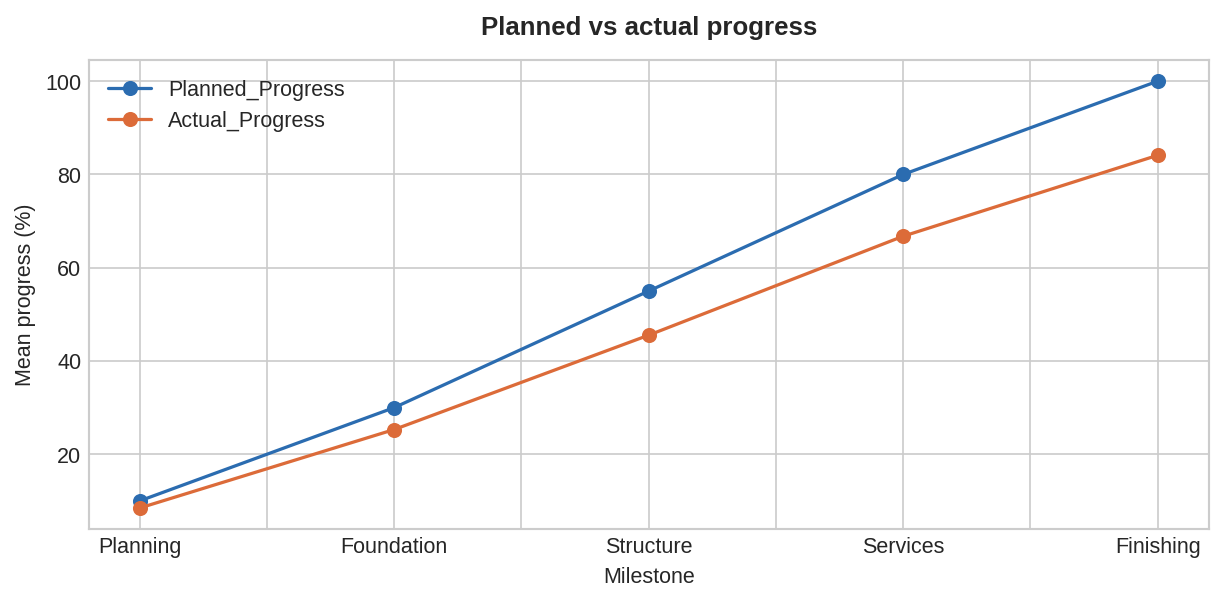

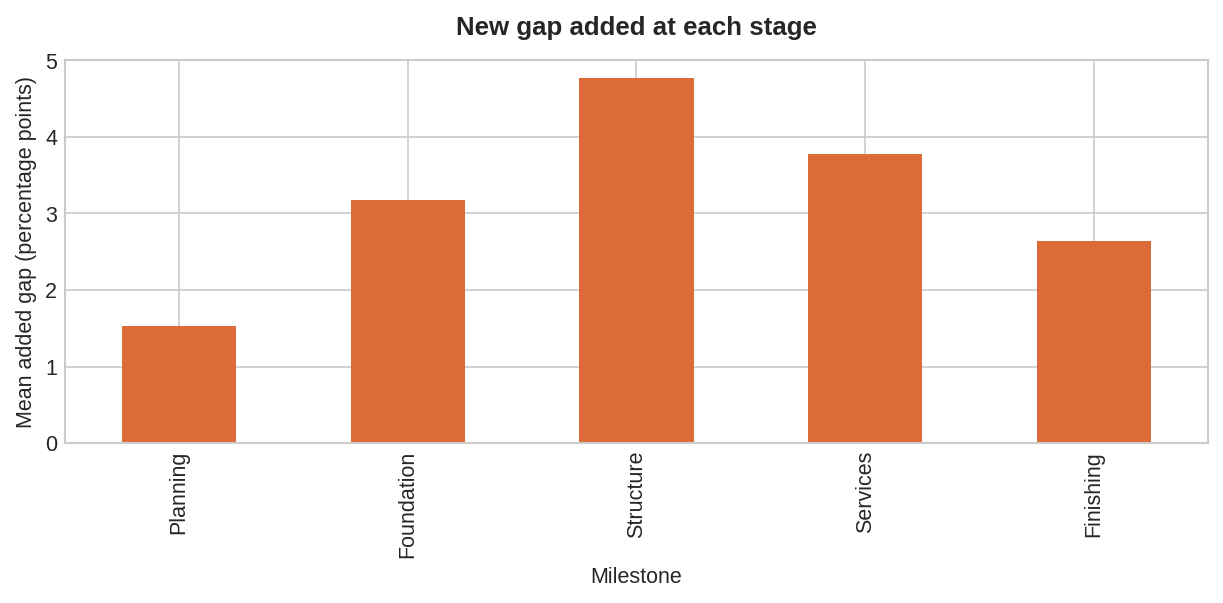

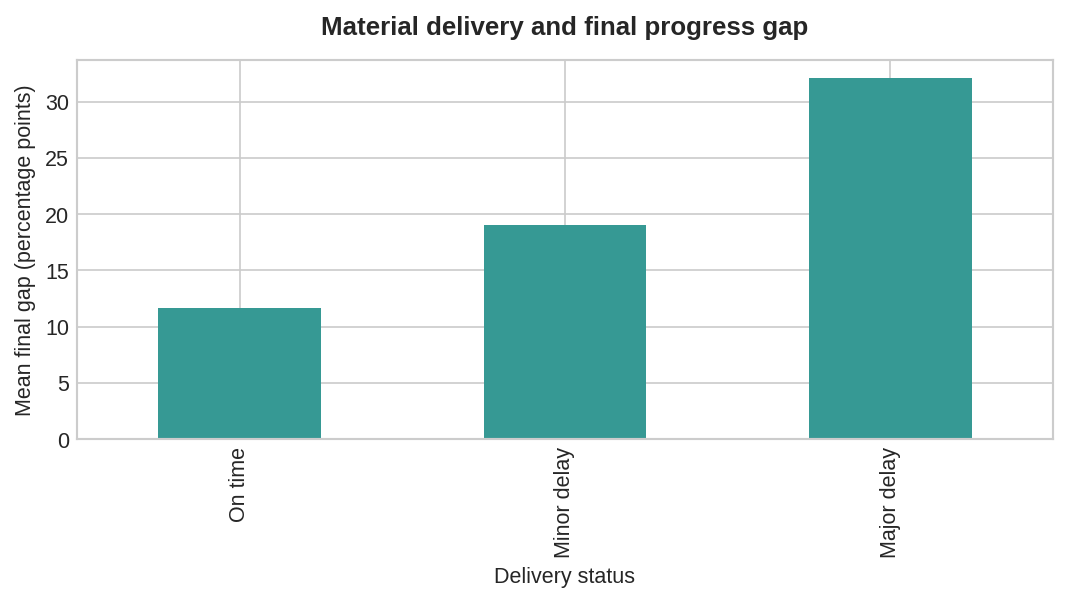

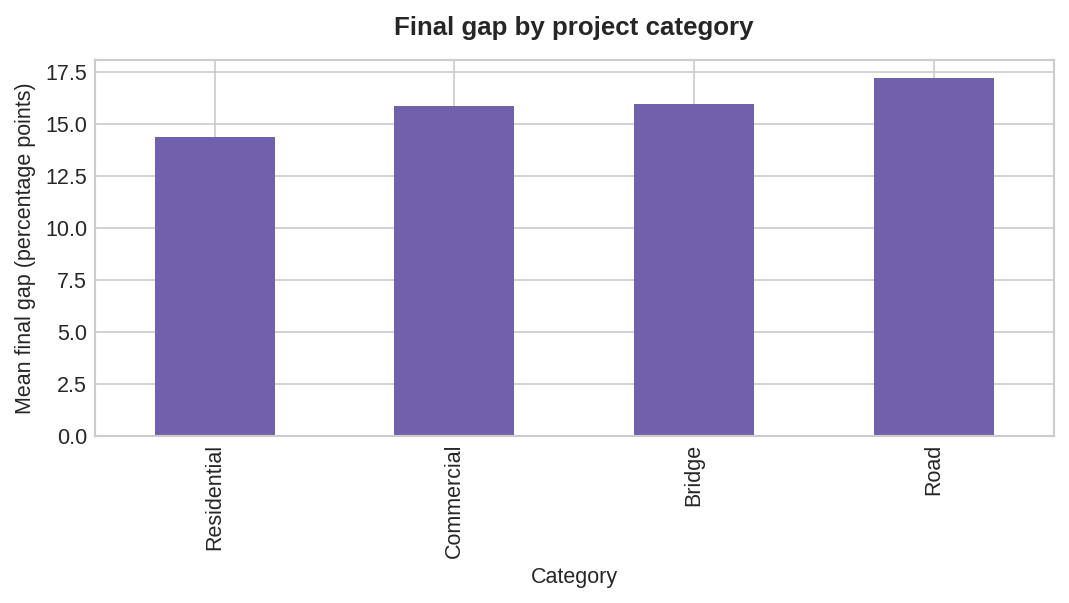

In [7]:
from IPython.display import Image, display
for image_name in ["01_progress.png", "02_stage_gap.png", "03_materials.png", "04_categories.png"]:
    display(Image(filename=str(CHARTS / image_name)))

## 5. Evaluation and interpretation

In [8]:
result = json.loads((OUT / "summary.json").read_text())
m = result["metrics"]
print("Held-out projects:", m["test_projects"])
print("Accuracy:", m["accuracy"], "ROC AUC:", m["roc_auc"])
print("Delayed-class precision:", round(m["classification_report"]["1"]["precision"], 3))
print("Delayed-class recall:", round(m["classification_report"]["1"]["recall"], 3))
print("Confusion matrix [not delayed, delayed]:", m["confusion_matrix"])
print("\nSeven generated insights:")
for i, item in enumerate(result["insights"], 1): print(f"{i}. {item}")
print("\nAction plan:")
for i, item in enumerate(result["actions"], 1): print(f"{i}. {item}")

Held-out projects: 100
Accuracy: 0.83 ROC AUC: 0.885
Delayed-class precision: 0.9
Delayed-class recall: 0.863
Confusion matrix [not delayed, delayed]: [[20, 7], [10, 63]]

Seven generated insights:
1. 277 of 400 projects (69.2%) finished at least 10 points behind plan.
2. Mean final progress gap was 15.9 percentage points.
3. The largest average new gap occurred at Structure (4.8 points).
4. Major material delays coincided with a 32.1-point final gap versus 11.7 for on-time deliveries.
5. Road had the highest mean final gap (17.2 points) among categories.
6. Severe weather projects had a 26.1-point mean gap versus 12.9 under clear weather.
7. Contractor D had the largest mean final gap (16.5 points); project mix may explain some of this difference.

Action plan:
1. Review procurement commitments before foundation work begins.
2. Flag foundation-stage gaps and review affected projects weekly.
3. Add weather contingency to stage schedules and verify crew availability.
4. Investigate cont

## 6. Download outputs for GitHub
The notebook itself is saved through **File → Save a copy in GitHub**. Download this ZIP and add its CSV, charts, and summary to the same repository using GitHub **Add file → Upload files**. Keep the model file optional; the notebook can retrain it.

In [9]:
import shutil
archive = shutil.make_archive("construction_delay_outputs", "zip", root_dir=str(ROOT), base_dir="outputs")
print("Download:", archive)
try:
    from google.colab import files
    files.download(archive)
except ImportError:
    print("Colab-only download helper unavailable in this environment.")

Download: /content/construction_delay_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Limitations
This is a controlled synthetic demonstration. The model learns simulation assumptions; the scores are not evidence of predictive performance on real projects. `Final_Delay` is a final progress proxy, not measured completion days. Association does not establish causation.